In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# DATA CLEANING AND PREPROCESSING

In [3]:
df = pd.read_csv('/Users/akshayrana/Desktop/sentiment analysis/twitter_training.csv')

In [4]:
df = df.iloc[:, 2:]
df.columns = ["Sentiment", "Text"]

In [5]:
df.info()
df.shape
df.isnull().sum()
df["Sentiment"].unique()
df["Sentiment"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentiment  74681 non-null  object
 1   Text       73995 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


Sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [6]:
df = df[df["Sentiment"] != "Irrelevant"]
df = df.dropna(subset=["Text"])

In [7]:
df[df.duplicated()]
df.duplicated().sum()
df = df.drop_duplicates()

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["label"] = le.fit_transform(df["Sentiment"])
print(le.classes_)

['Negative' 'Neutral' 'Positive']


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
df = df.head(2000)

In [12]:
df.shape

(2000, 3)

# MODEL SELECTION 

In [13]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_sentiments, test_sentiments = train_test_split(
    df["Text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)
print(train_texts.shape)
print(test_texts.shape)

print(train_sentiments.value_counts())

(1600,)
(400,)
label
2    784
1    466
0    350
Name: count, dtype: int64


In [14]:
from transformers import AutoTokenizer

In [15]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [18]:
from datasets import Dataset

In [19]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_sentiments.tolist()
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": test_sentiments.tolist()
})

In [20]:
print(train_dataset[0])

{'input_ids': [101, 4638, 2041, 2023, 8680, 5460, 2121, 999, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'labels': 1}


In [21]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# MODEL  TRAINING

In [26]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to="none"
)

In [27]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

In [28]:
trainer.train()

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.060754


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=600, training_loss=0.05542731324831645, metrics={'train_runtime': 191.4722, 'train_samples_per_second': 25.069, 'train_steps_per_second': 3.134, 'total_flos': 158963713228800.0, 'train_loss': 0.05542731324831645, 'epoch': 3.0})

In [29]:
predictions = trainer.predict(test_dataset)

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [30]:
logits = predictions.predictions

In [31]:
logits

array([[-2.7737527, -3.1195874,  5.809832 ],
       [-2.6381946,  5.8334618, -2.109316 ],
       [-2.904682 , -2.990749 ,  5.8114924],
       ...,
       [-2.8168998, -2.7076535,  5.4333754],
       [-2.3659832,  5.9758534, -2.6258533],
       [-2.6938534,  5.895515 , -2.2349784]], dtype=float32)

In [34]:
import torch

probabilities = torch.softmax(
    torch.tensor(logits),
    dim=1
)
percentages = probabilities * 100
print(percentages)

tensor([[1.8709e-02, 1.3239e-02, 9.9968e+01],
        [2.0920e-02, 9.9944e+01, 3.5502e-02],
        [1.6386e-02, 1.5035e-02, 9.9969e+01],
        ...,
        [2.6104e-02, 2.9118e-02, 9.9945e+01],
        [2.3823e-02, 9.9958e+01, 1.8371e-02],
        [1.8598e-02, 9.9952e+01, 2.9428e-02]])


In [39]:
predicted_labels = probabilities.argmax(dim=1)

In [40]:
confidence_scores = probabilities.max(dim=1).values

In [41]:
label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

In [42]:
for i in range(10):
    print("Tweet:")
    print(test_texts.iloc[i])

    print("Prediction:",
          label_map[predicted_labels[i].item()])

    print("Confidence:",
          f"{confidence_scores[i].item() * 100:.2f}%")

    print("-" * 80)

Tweet:
Atleast I have Borderlands to cheer me up :(
Prediction: Positive
Confidence: 99.97%
--------------------------------------------------------------------------------
Tweet:
Sky Rocket > a SuperBadass or Caustic for Goliath. Borderlands 2
Prediction: Neutral
Confidence: 99.94%
--------------------------------------------------------------------------------
Tweet:
did we really play and many hours of for...? it actually really fun though!
Prediction: Positive
Confidence: 99.97%
--------------------------------------------------------------------------------
Tweet:
My favorite games I guess?... 1. Minecraft. Can't ever beat that.. 2. Plants Vs. Zombies - First video game I played. 3. Borders 2 - Thank @ DarkyMaine for this. 4. Undertale / Darune. 5. Mario Kart 8 Deluxe... Dibs on @ Art _ Author and @ Robang592 to try this
Prediction: Positive
Confidence: 99.97%
--------------------------------------------------------------------------------
Tweet:
Borderlands 3. Firebug (Bronze): S

# METRICS (ACCURACY , CLASSIFICATION REPORT)

In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    predictions.label_ids,
    predicted_labels.numpy()
)

print("Accuracy:", accuracy)

Accuracy: 0.9675


In [44]:
from sklearn.metrics import classification_report

print(
    classification_report(
        predictions.label_ids,
        predicted_labels.numpy(),
        target_names=["Negative", "Neutral", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.99      0.94      0.96        87
     Neutral       0.94      0.97      0.96       117
    Positive       0.97      0.97      0.97       196

    accuracy                           0.97       400
   macro avg       0.97      0.96      0.97       400
weighted avg       0.97      0.97      0.97       400



In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    predictions.label_ids,
    predicted_labels.numpy()
)

print(cm)

[[ 82   2   3]
 [  1 114   2]
 [  0   5 191]]


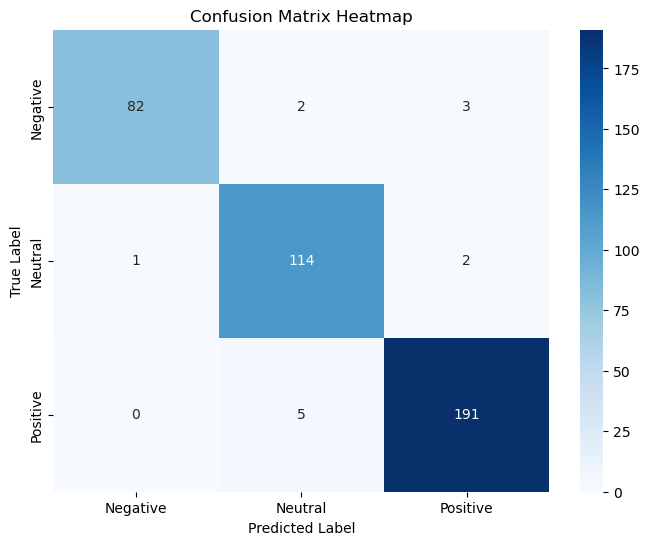

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["Negative", "Neutral", "Positive"]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

# STREAMLIT

In [55]:
!pip install streamlit

4511.79s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [57]:
trainer.save_model("./sentiment_model")
tokenizer.save_pretrained("./sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./sentiment_model/tokenizer_config.json', './sentiment_model/tokenizer.json')

In [59]:
import streamlit as st
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("sentiment_model")
model = AutoModelForSequenceClassification.from_pretrained(
    "sentiment_model"
)

# Label mapping
label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

st.title("Sentiment Analysis")
st.write(
    "Enter a sentence and predict its sentiment using DistilBERT."
)

text = st.text_area(
    "Enter Text",
    placeholder="Type your sentence here..."
)

if st.button("Predict"):

    if text.strip() == "":
        st.warning("Please enter some text.")
    else:

        encoding = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )

        with torch.no_grad():
            outputs = model(**encoding)

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )[0]

        predicted_class = torch.argmax(
            probabilities
        ).item()

        st.success(
            f"Predicted Sentiment: "
            f"{label_map[predicted_class]}"
        )

        st.subheader("Confidence Scores")

        st.write(
            f"🔴 Negative: "
            f"{probabilities[0].item()*100:.2f}%"
        )

        st.write(
            f"🟡 Neutral: "
            f"{probabilities[1].item()*100:.2f}%"
        )

        st.write(
            f"🟢 Positive: "
            f"{probabilities[2].item()*100:.2f}%"
        )

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

2026-06-17 13:21:11.468 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13:21:11.469 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13:21:11.469 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13:21:11.469 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13:21:11.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13:21:11.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13:21:11.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 13:21:11.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar